<a href="https://colab.research.google.com/github/tuonglab/dandelion/blob/fix-colab-tut/container/dandelion_singularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to `dandelion`
<img src='https://github.com/zktuong/dandelion/blob/master/docs/notebooks/img/dandelion_logo_illustration.png?raw=true'/>

Welcome to the Google Colab notebook example/tutorial for Dandelion! In this notebook, we will run through an example workflow for 1) pre-processing, 2) post-processing and 3) pseudobulk V(D)J trajectory.

## Installation

In [1]:
# non-dandelion dependencies to run the full tutorial notebook
!pip install -q scanpy[leiden] pandas==2.2.2 "scipy<1.15.0"
# So we will use the soon-to-be archived `milopy` package while downgrading `scipy` to get it to work here.
!pip install -q git+https://github.com/emdann/milopy.git palantir


# install Dandelion
# here, we will install from the github repo, but usually it should be:
# pip install -q sc-dandelion[polars]
!pip install -q "sc-dandelion[polars] @ git+https://github.com/tuonglab/dandelion.git@fix-colab-tut"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 11.3 MB/s eta 0:00:00
  Installing 

In [2]:
# import and show versions
import dandelion as ddl
import scanpy as sc

ddl.logging.print_header()

dandelion==1.0.0a1.dev51 pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 networkx==3.6.1 scipy==1.14.1


## Preprocessing - V(D)J reannotation

We will try out the full reannotation workflow in this part of the colab notebook. We will use the [singularity container](https://sc-dandelion.readthedocs.io/en/latest/notebooks/Q1-singularity-preprocessing.html) to simplify this process.

In [3]:
from dandelion.tutorial import setup_colab_singularity

setup_colab_singularity()


✅ Singularity / Apptainer ready!


In [4]:
# now actually pull the image. Will take a few minutes.
!singularity pull library://kt16/default/sc-dandelion:latest

INFO:    Downloading library image


### Download example datasets from 10X

We will download example datasets freely available from 10X Genomics.

In [5]:
from dandelion.tutorial import setup_dandelion_tutorial_bcr

setup_dandelion_tutorial_bcr()

To keep this part of the tutorial short, we will trim to just 1000 contigs in each file but definitely do try it again later on the full datasets (by deleting/commenting the code block below)!

In [6]:
%%shell
# trim to just 1000 contigs to make this part of the tutorial shorter
# helper function style
trim_dataset () {
  dir="$1"

  cd "$dir"

  # FASTA: keep first 1000 records (NOT lines, but ok approximation if single-line seqs)
  awk 'NR<=1000' filtered_contig.fasta > tmp.fasta && mv tmp.fasta filtered_contig.fasta

  # CSV: keep header + first 1000 data rows
  head -n 1001 filtered_contig_annotations.csv > tmp.csv && mv tmp.csv filtered_contig_annotations.csv
}

# now actually run the trimming
trim_dataset /content/dandelion_tutorial/vdj_v1_hs_pbmc3_b
trim_dataset /content/dandelion_tutorial/vdj_nextgem_hs_pbmc3_b
trim_dataset /content/dandelion_tutorial/sc5p_v2_hs_PBMC_10k_b
trim_dataset /content/dandelion_tutorial/sc5p_v2_hs_PBMC_1k_b

## Preprocessing 10X data

We will use the downloaded `singularity` image/container to run the full preprocessing pipeline. Internally, the steps in the container will just follow the [detailed tutorial](https://sc-dandelion.readthedocs.io/en/latest/notebooks/base/1_dandelion_preprocessing-10x_data.html).

In [7]:
# first, create a meta.csv holding the info
import pandas as pd

meta = pd.DataFrame(
    {
        "sample": [
            "sc5p_v2_hs_PBMC_1k_b",
            "sc5p_v2_hs_PBMC_10k_b",
            "vdj_v1_hs_pbmc3_b",
            "vdj_nextgem_hs_pbmc3_b",
        ],
        "suffix": [
            "sc5p_v2_hs_PBMC_1k_b",
            "sc5p_v2_hs_PBMC_10k_b",
            "vdj_v1_hs_pbmc3_b",
            "vdj_nextgem_hs_pbmc3_b",
        ],
        "individual": [
            "sc5p_v2_hs",
            "sc5p_v2_hs",
            "vdj_v1_hs",
            "vdj_v1_hs",
        ]
    }
)
meta.to_csv("/content/dandelion_tutorial/meta.csv", index=False)
# here's what it looks like
meta

,sample,suffix,individual
0,sc5p_v2_hs_PBMC_1k_b,sc5p_v2_hs_PBMC_1k_b,sc5p_v2_hs
1,sc5p_v2_hs_PBMC_10k_b,sc5p_v2_hs_PBMC_10k_b,sc5p_v2_hs
2,vdj_v1_hs_pbmc3_b,vdj_v1_hs_pbmc3_b,vdj_v1_hs
3,vdj_nextgem_hs_pbmc3_b,vdj_nextgem_hs_pbmc3_b,vdj_v1_hs


In [8]:
%%shell
set -e

export MPLBACKEND=Agg # so that this works on colab

cd /content/dandelion_tutorial # make sure to change into the directory where the folders are

singularity run \
  -B $PWD \
  /content/sc-dandelion_latest.sif \
  dandelion-preprocess \
  --meta meta.csv \
  --file_prefix filtered \
  --clean_output

# to see all the available options with the singularity image, do:
# singularity run -B $PWD /content/sc-dandelion_latest.sif dandelion-preprocess --help

/opt/conda/envs/sc-dandelion-container/lib/python3.12/site-packages/nxviz/__init__.py:33: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)

Software versions:

dandelion==0.5.4 pandas==2.2.3 numpy==2.1.3 matplotlib==3.10.1 networkx==3.4.2 scipy==1.15.2

Begin preprocessing

command line parameters:
: --------------------------------------------------------------
    --meta = meta.csv
    --chain = ig
    --org = human
    --file_prefix = filtered
    --db = imgt
    --strain = None
    --sep = _
    --flavour = strict
    --filter_to_high_

And now we have a processed output (`filtered_contig_dandelion.tsv`) in each folder that can be used for downstream exploration.

# Post-processing - V(D)J analysis

We will now switch to the post-processing tutorial. Let's follow the rest of the [original tutorial](https://sc-dandelion.readthedocs.io/en/latest/notebooks/Q2-analysis.html).

In [9]:
from dandelion.tutorial import setup_dandelion_tutorial_simple

setup_dandelion_tutorial_simple()

Downloading...
From (original): https://drive.google.com/uc?id=1-PrwDi1Py8jqioNtP0DISKrcShRRHKxk
From (redirected): https://drive.google.com/uc?id=1-PrwDi1Py8jqioNtP0DISKrcShRRHKxk&confirm=t&uuid=b37bf446-4671-457e-ba1a-14db395841ff
To: /content/dandelion_tutorial/simple_demo/demo-gex.h5ad
100%|██████████| 578M/578M [00:06<00:00, 96.0MB/s]


Downloading...
From: https://drive.google.com/uc?id=1-d_uah-NzJqDYRP53ICgAAquiVLWRRtN
To: /content/dandelion_tutorial/simple_demo/demo-vdj.h5ddl
100%|██████████| 19.9M/19.9M [00:00<00:00, 66.2MB/s]


Let’s run through some of what `Dandelion` can do in terms of analysis. In order to kickstart this tutorial, we prepared GEX and V(D)J objects with four demo 10X samples parsed for your convenience. You can download them from the ftp site as per below. The GEX has had some basic `Scanpy` analysis performed on it, all the way up to making a UMAP and calling Leiden clusters. The VDJ is just four calls of `ddl.read_10x_airr()`, with the individual objects saved to a list, which was then passed to `ddl.concat()` to get a combined `Dandelion` object. No analysis was done on this combined object.

Let’s import the objects. `Dandelion`’s h5ddl files can be read via `ddl.read_h5ddl()`.

In [10]:
adata = sc.read("dandelion_tutorial/simple_demo/demo-gex.h5ad")
vdj = ddl.read_h5ddl("dandelion_tutorial/simple_demo/demo-vdj.h5ddl")
# to read in a new airr formatted file, you would use something like:
# vdj = ddl.read_airr("filtered_contig_dandelion.tsv")

At this point you’re probably wondering why there’s a separate Dandelion object. The reason is AIRR compliance. Some of the AIRR columns have more complex typing than what Scanpy can currently support within its objects. However, it’s quite straightforward to link up a Scanpy object with a `Dandelion` one.

In [11]:
vdj, adata = ddl.pp.check_contigs(vdj, adata)

Filtering contigs...
Marking ambiguous contigs...
Initializing DandelionPolars object...


This filters the contigs and synchronises relevant information between the objects. Once linked up like this, any new information can be copied over from the Dandelion object via `ddl.tl.transfer()`.

For now, let’s take a look at the chain status (as gotten from the Dandelion object) and known BCR marker expression.

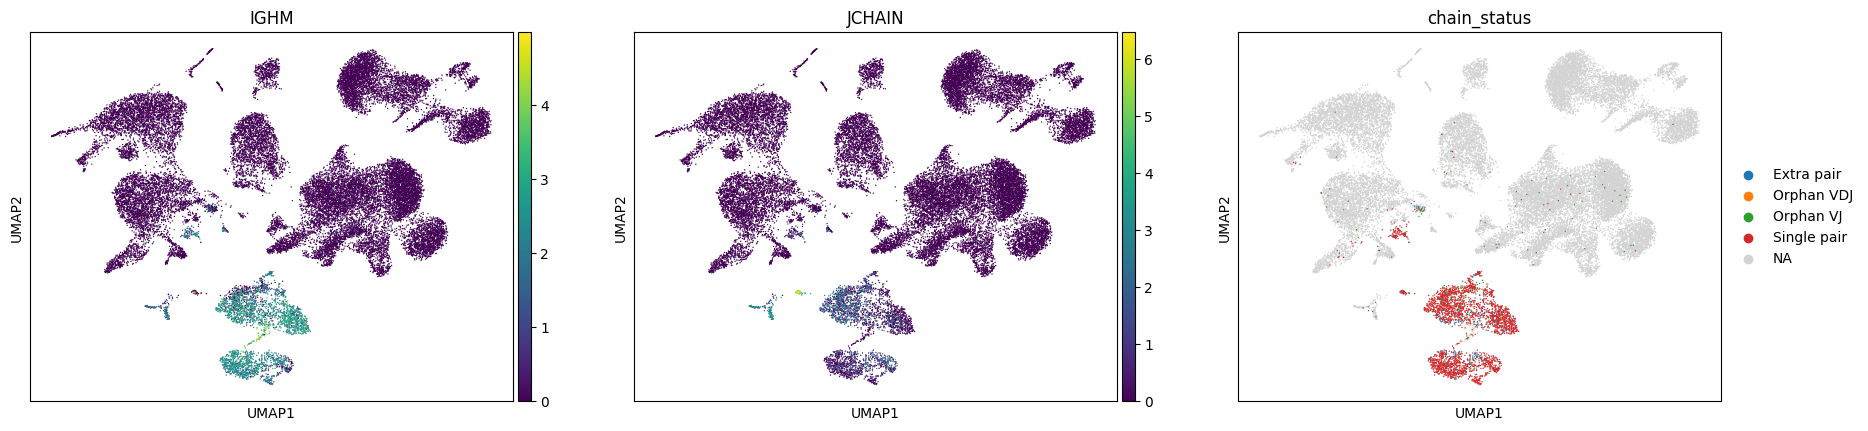

In [12]:
sc.pl.umap(adata, color=["IGHM", "JCHAIN", "chain_status"])

Under the hood, the `Dandelion` object is essentially two data frames. `.data` holds the AIRR-compliant contig space table, while `.metadata` is an `.obs` equivalent that parses the contig information to a cell level and can be easily integrated with a `Scanpy` object. There are also `ddl.to_scirpy()` and `ddl.from_scirpy()` for interoperability with `Scirpy`, as explored in a notebook in the extended tutorial.

In [13]:
vdj

Lazy Dandelion object with n_obs = 3094 and n_contigs = 6253
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, c_call, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_support_igblastn, j_score_igblastn, j_call_igblastn, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_star

In [14]:
# as we are using polars here, the default is a LazyFrame. We can materialise it into memory with .collect()
vdj.metadata.collect()

cell_id,sample_id,productive_VDJ,productive_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,junction_VDJ,junction_VJ,junction_aa_VDJ,junction_aa_VJ,locus_VDJ,locus_VJ,c_call_VDJ,c_call_VJ,v_call_VDJ,v_call_VJ,umi_count_VDJ,umi_count_VJ,productive_VDJ_main,productive_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,junction_VDJ_main,junction_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,locus_VDJ_main,locus_VJ_main,c_call_VDJ_main,c_call_VJ_main,v_call_genotyped_VDJ_main,v_call_genotyped_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,isotype,isotype_main,isotype_status,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str
"""sc5p_v2_hs_PBMC_10k_AAACCTGTCA…","""sc5p_v2_hs_PBMC_10k""",null,"""T""",null,null,"""IGKJ4""",null,"""TGTCAACAATATGACGAACTTCCCGTCACT…",null,"""CQQYDELPVTF""",null,"""IGK""",null,"""IGKC""",null,"""IGKV1-33*01,IGKV1D-33*01""",0,68,null,"""T""",null,null,"""IGKJ4""",null,"""TGTCAACAATATGACGAACTTCCCGTCACT…",null,"""CQQYDELPVTF""",null,"""IGK""",null,"""IGKC""",null,"""IGKV1-33*01,IGKV1D-33*01""",null,68.0,null,null,null,"""Orphan IGK""","""Orphan VJ""",null,"""Standard"""
"""sc5p_v2_hs_PBMC_10k_AAACCTGTCC…","""sc5p_v2_hs_PBMC_10k""","""T""","""T""","""IGHD3-22""","""IGHJ3""","""IGKJ1""","""TGTGCGACTACGTATTACTATGATAGTAGT…","""TGTCAACAGTATTATAGTTACCCTCGGACG…","""CATTYYYDSSGYYQNDAFDIW""","""CQQYYSYPRTF""","""IGH""","""IGK""","""IGHM""","""IGKC""","""IGHV1-69*01""","""IGKV1-8*01""",51,43,"""T""","""T""","""IGHD3-22""","""IGHJ3""","""IGKJ1""","""TGTGCGACTACGTATTACTATGATAGTAGT…","""TGTCAACAGTATTATAGTTACCCTCGGACG…","""CATTYYYDSSGYYQNDAFDIW""","""CQQYYSYPRTF""","""IGH""","""IGK""","""IGHM""","""IGKC""","""IGHV1-69*01""","""IGKV1-8*01""",51.0,43.0,"""IgM""","""IgM""","""IgM""","""IGH + IGK""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_AAACCTGTCG…","""sc5p_v2_hs_PBMC_10k""","""T""","""T""",null,"""IGHJ3""","""IGLJ3""","""TGTGCGAGAGAGATAGAGGGGGACGGTGTT…","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…","""CAREIEGDGVFEIW""","""CMIWHSSAWVV""","""IGH""","""IGL""","""IGHM""","""IGLC3""","""IGHV1-2*02""","""IGLV5-45*02""",47,90,"""T""","""T""",null,"""IGHJ3""","""IGLJ3""","""TGTGCGAGAGAGATAGAGGGGGACGGTGTT…","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…","""CAREIEGDGVFEIW""","""CMIWHSSAWVV""","""IGH""","""IGL""","""IGHM""","""IGLC3""","""IGHV1-2*02""","""IGLV5-45*02""",47.0,90.0,"""IgM""","""IgM""","""IgM""","""IGH + IGL""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_AAACCTGTCT…","""sc5p_v2_hs_PBMC_10k""","""T""","""T""",null,"""IGHJ3""","""IGKJ2""","""TGTGCGAGACATATCCGTGGGAACAGATTT…","""TGTCAACAGTATTATAGTTTCCCGTACACT…","""CARHIRGNRFGNDAFDIW""","""CQQYYSFPYTF""","""IGH""","""IGK""","""IGHM""","""IGKC""","""IGHV5-51*03""","""IGKV1D-8*01""",80,22,"""T""","""T""",null,"""IGHJ3""","""IGKJ2""","""TGTGCGAGACATATCCGTGGGAACAGATTT…","""TGTCAACAGTATTATAGTTTCCCGTACACT…","""CARHIRGNRFGNDAFDIW""","""CQQYYSFPYTF""","""IGH""","""IGK""","""IGHM""","""IGKC""","""IGHV5-51*03""","""IGKV1D-8*01""",80.0,22.0,"""IgM""","""IgM""","""IgM""","""IGH + IGK""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_AAACGGGAGC…","""sc5p_v2_hs_PBMC_10k""","""T""","""T""","""IGHD6-13""","""IGHJ3""","""IGLJ2""","""TGTGCGAGAGTAGGCTATAGAGCAGCAGCT…","""TGTAACTCCCGGGACAGCAGTGGTAACCAT…","""CARVGYRAAAGTDAFDIW""","""CNSRDSSGNHVVF""","""IGH""","""IGL""","""IGHM""","""IGLC""","""IGHV4-4*07""","""IGLV3-19*01""",18,14,"""T""","""T""","""IGHD6-13""","""IGHJ3""","""IGLJ2""","""TGTGCGAGAGTAGGCTATAGAGCAGCAGCT…","""TGTAACTCCCGGGACAGCAGTGGTAACCAT…","""CARVGYRAAAGTDAFDIW""","""CNSRDSSGNHVVF""","""IGH""","""IGL""","""IGHM""","""IGLC""","""IGHV4-4*07""","""IGLV3-19*01""",18.0,14.0,"""IgM""","""IgM""","""IgM""","""IGH + IGL""","""Single pair""","""Standard""","""Standard"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

Now that we’ve got the gist of basic handling of the `Dandelion` object, let’s use it for some analysis!

A core element of V(D)J analysis is clonotype calling, roughly equivalent to clustering cells in GEX processing. `Dandelion` requires the clones it calls to have identical V and J genes, along with no more than 15% mismatches in the CDR3 sequences (common practice in BCR analysis).

Before we run that though, let's simplify the data to disambiguate VDJ and C gene calls when there’s multiple calls separated by commas and strip the alleles.

In [15]:
vdj.simplify()
vdj.metadata.collect()

cell_id,sample_id,productive_VDJ,productive_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,junction_VDJ,junction_VJ,junction_aa_VDJ,junction_aa_VJ,locus_VDJ,locus_VJ,c_call_VDJ,c_call_VJ,v_call_VDJ,v_call_VJ,umi_count_VDJ,umi_count_VJ,productive_VDJ_main,productive_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,junction_VDJ_main,junction_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,locus_VDJ_main,locus_VJ_main,c_call_VDJ_main,c_call_VJ_main,v_call_genotyped_VDJ_main,v_call_genotyped_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,isotype,isotype_main,isotype_status,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str
"""sc5p_v2_hs_PBMC_10k_AAACCTGTCA…","""sc5p_v2_hs_PBMC_10k""",null,"""T""",null,null,"""IGKJ4""",null,"""TGTCAACAATATGACGAACTTCCCGTCACT…",null,"""CQQYDELPVTF""",null,"""IGK""",null,"""IGKC""",null,"""IGKV1-33""",0,68,null,"""T""",null,null,"""IGKJ4""",null,"""TGTCAACAATATGACGAACTTCCCGTCACT…",null,"""CQQYDELPVTF""",null,"""IGK""",null,"""IGKC""",null,"""IGKV1-33""",null,68.0,null,null,null,"""Orphan IGK""","""Orphan VJ""",null,"""Standard"""
"""sc5p_v2_hs_PBMC_10k_AAACCTGTCC…","""sc5p_v2_hs_PBMC_10k""","""T""","""T""","""IGHD3-22""","""IGHJ3""","""IGKJ1""","""TGTGCGACTACGTATTACTATGATAGTAGT…","""TGTCAACAGTATTATAGTTACCCTCGGACG…","""CATTYYYDSSGYYQNDAFDIW""","""CQQYYSYPRTF""","""IGH""","""IGK""","""IGHM""","""IGKC""","""IGHV1-69""","""IGKV1-8""",51,43,"""T""","""T""","""IGHD3-22""","""IGHJ3""","""IGKJ1""","""TGTGCGACTACGTATTACTATGATAGTAGT…","""TGTCAACAGTATTATAGTTACCCTCGGACG…","""CATTYYYDSSGYYQNDAFDIW""","""CQQYYSYPRTF""","""IGH""","""IGK""","""IGHM""","""IGKC""","""IGHV1-69""","""IGKV1-8""",51.0,43.0,"""IgM""","""IgM""","""IgM""","""IGH + IGK""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_AAACCTGTCG…","""sc5p_v2_hs_PBMC_10k""","""T""","""T""",null,"""IGHJ3""","""IGLJ3""","""TGTGCGAGAGAGATAGAGGGGGACGGTGTT…","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…","""CAREIEGDGVFEIW""","""CMIWHSSAWVV""","""IGH""","""IGL""","""IGHM""","""IGLC3""","""IGHV1-2""","""IGLV5-45""",47,90,"""T""","""T""",null,"""IGHJ3""","""IGLJ3""","""TGTGCGAGAGAGATAGAGGGGGACGGTGTT…","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…","""CAREIEGDGVFEIW""","""CMIWHSSAWVV""","""IGH""","""IGL""","""IGHM""","""IGLC3""","""IGHV1-2""","""IGLV5-45""",47.0,90.0,"""IgM""","""IgM""","""IgM""","""IGH + IGL""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_AAACCTGTCT…","""sc5p_v2_hs_PBMC_10k""","""T""","""T""",null,"""IGHJ3""","""IGKJ2""","""TGTGCGAGACATATCCGTGGGAACAGATTT…","""TGTCAACAGTATTATAGTTTCCCGTACACT…","""CARHIRGNRFGNDAFDIW""","""CQQYYSFPYTF""","""IGH""","""IGK""","""IGHM""","""IGKC""","""IGHV5-51""","""IGKV1D-8""",80,22,"""T""","""T""",null,"""IGHJ3""","""IGKJ2""","""TGTGCGAGACATATCCGTGGGAACAGATTT…","""TGTCAACAGTATTATAGTTTCCCGTACACT…","""CARHIRGNRFGNDAFDIW""","""CQQYYSFPYTF""","""IGH""","""IGK""","""IGHM""","""IGKC""","""IGHV5-51""","""IGKV1D-8""",80.0,22.0,"""IgM""","""IgM""","""IgM""","""IGH + IGK""","""Single pair""","""Standard""","""Standard"""
"""sc5p_v2_hs_PBMC_10k_AAACGGGAGC…","""sc5p_v2_hs_PBMC_10k""","""T""","""T""","""IGHD6-13""","""IGHJ3""","""IGLJ2""","""TGTGCGAGAGTAGGCTATAGAGCAGCAGCT…","""TGTAACTCCCGGGACAGCAGTGGTAACCAT…","""CARVGYRAAAGTDAFDIW""","""CNSRDSSGNHVVF""","""IGH""","""IGL""","""IGHM""","""IGLC""","""IGHV4-4""","""IGLV3-19""",18,14,"""T""","""T""","""IGHD6-13""","""IGHJ3""","""IGLJ2""","""TGTGCGAGAGTAGGCTATAGAGCAGCAGCT…","""TGTAACTCCCGGGACAGCAGTGGTAACCAT…","""CARVGYRAAAGTDAFDIW""","""CNSRDSSGNHVVF""","""IGH""","""IGL""","""IGHM""","""IGLC""","""IGHV4-4""","""IGLV3-19""",18.0,14.0,"""IgM""","""IgM""","""IgM""","""IGH + IGL""","""Single pair""","""Standard""","""Standard"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""vdj_v1_hs_pbmc3_TTTCCTCAGCGCTT…","""vdj_v1_hs_pbmc3""","""T""","""T"

In [16]:
ddl.tl.find_clones(vdj)

Using NumPy backend (CPU only)


Finding clones based on B cell VDJ chains using junction_aa: 100%|██████████| 1277/1277 [00:00<00:00, 2628.52it/s]
Finding clones based on B cell VJ chains using junction_aa: 100%|██████████| 527/527 [00:00<00:00, 2324.63it/s]
Building distance matrix (batched): 100%|██████████| 19/19 [00:00<00:00, 730.88it/s]


Lazy Dandelion object with n_obs = 3094 and n_contigs = 6253
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, c_call, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_support_igblastn, j_score_igblastn, j_call_igblastn, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_star

We can compute a graph based on Levenshtein distance of the complete contig sequence. A NetworkX representation of it is now saved in `vdj.graph`.

In [17]:
ddl.tl.generate_network(vdj)

Since we now know what our clonotype calls are, we can quantify clonal expansion. It’s possible to cap this at a desired maximum clonotype size.

In [18]:
ddl.tl.clone_size(vdj)
ddl.tl.clone_size(vdj, max_size=3)

Now that our Dandelion object has analysis information inside it, we can copy it over to the Scanpy object to have access to it there. The graph gets turned into the Scanpy standard forms of `.obsp['vdj_distances']` and `.obsp['vdj_connectivites']` for potential downstream use.

In [19]:
ddl.tl.transfer(adata, vdj)

Let’s take a look at what we made!

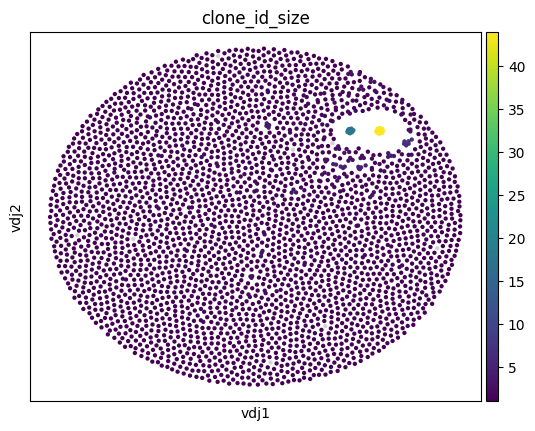

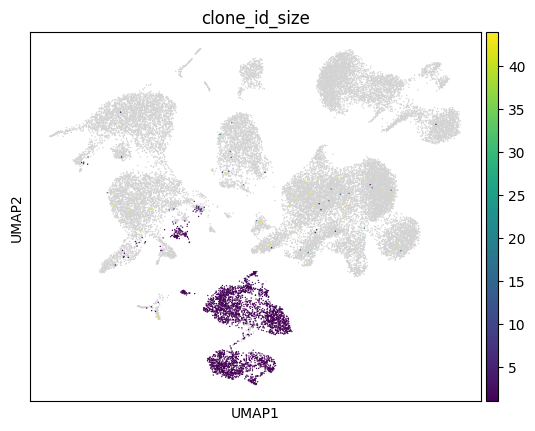

In [20]:
ddl.pl.clone_network(adata, color="clone_id_size")
sc.pl.umap(adata, color="clone_id_size")

Wait, why are we seeing some clone size 0 in the plots? Orphan chains.

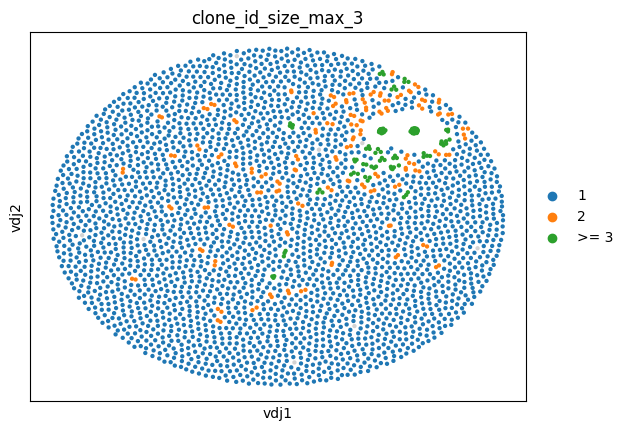

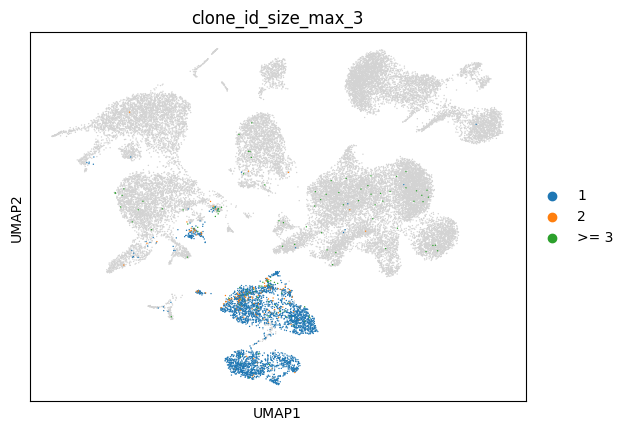

In [21]:
ddl.pl.clone_network(adata, color="clone_id_size_max_3", na_in_legend=False)
sc.pl.umap(adata, color="clone_id_size_max_3", na_in_legend=False)

Dandelion comes with a number of plotting functions for your convenience. However, those functions tend to operate best without the Scanpy plotting defaults in place. You can reset Matplotlib’s configuration prior to using them.

In [22]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
%matplotlib inline

We’ve got bar plots.

/usr/local/lib/python3.12/dist-packages/dandelion/polars/plotting/_plotting.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'v call VDJ usage'}, ylabel='proportion'>)

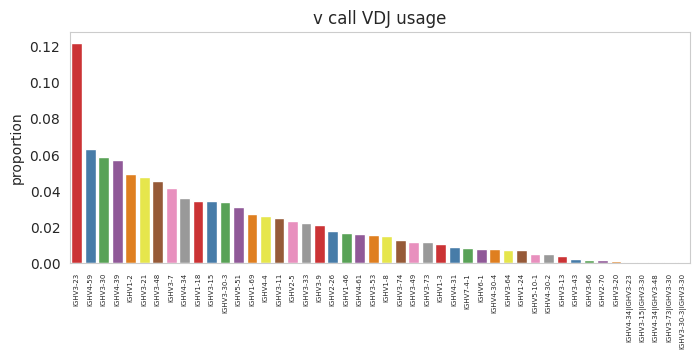

In [23]:
ddl.pl.barplot(
    vdj[vdj.metadata.isotype_status != "Multi"],  # remove multi from the plots
    color="v_call_VDJ",
    xtick_fontsize=5,
)

All of the plotting functions have a number of parameters that can be fiddled with for desired visualisation outcomes. For example, let’s disable automatic descending sorting, show counts rather than proportions, and change the palette.

/usr/local/lib/python3.12/dist-packages/dandelion/polars/plotting/_plotting.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'v call VDJ usage'}, ylabel='count'>)

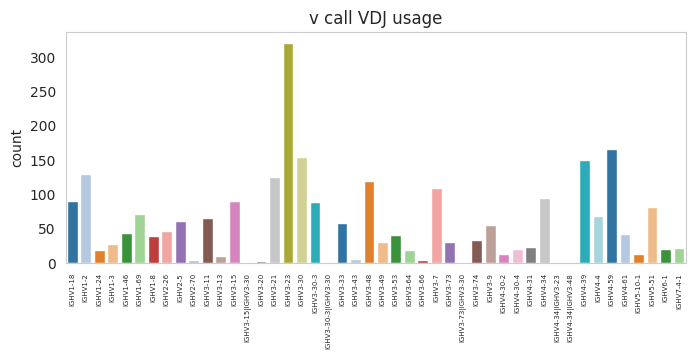

In [24]:
ddl.pl.barplot(
    vdj[vdj.metadata.isotype_status != "Multi"],
    color="v_call_VDJ",
    normalize=False,
    sort_descending=None,
    palette="tab20",
    xtick_fontsize=5,
)

We’ve got stacked bar plots.

(<Figure size 400x300 with 1 Axes>,
 <Axes: title={'center': 'multiple stacked bar plot : isotype status usage'}, xlabel='isotype_status', ylabel='count'>)

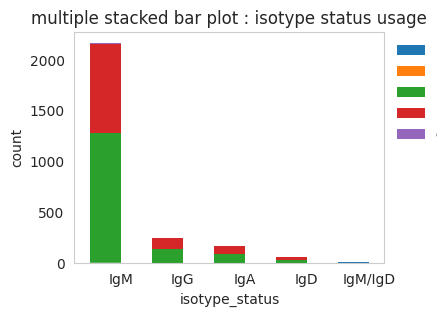

In [25]:
ddl.pl.stackedbarplot(
    vdj[vdj.metadata.isotype_status != "Multi"],
    color="isotype_status",
    group_by="locus_status",
    xtick_rotation=0,
    figsize=(4, 3),
)

These can be normalised to add up to 1 for each column.

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'multiple stacked bar plot : v call VDJ usage'}, xlabel='v_call_VDJ', ylabel='proportion'>)

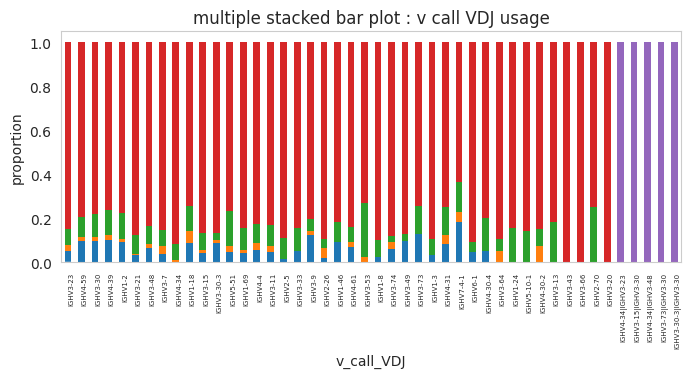

In [26]:
ddl.pl.stackedbarplot(
    vdj[vdj.metadata.isotype_status != "Multi"],
    color="v_call_VDJ",
    group_by="isotype_status",
    normalize=True,
    xtick_fontsize=5,
)

We’ve also got a spectratype plot, which shows the distribution of the CDR3 length for the various contigs.

(<Figure size 500x300 with 1 Axes>,
 <Axes: xlabel='junction_length', ylabel='count'>)

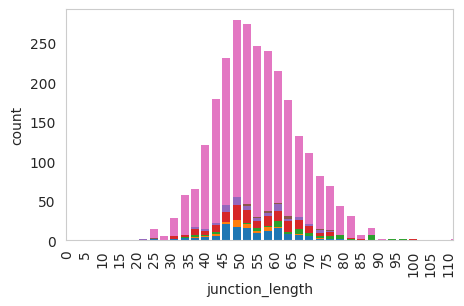

In [27]:
ddl.pl.spectratype(
    vdj[vdj.metadata.isotype_status != "Multi"],
    color="junction_length",
    group_by="c_call",
    locus="IGH",
    width=2.3,
)

Another common V(D)J analysis request is to examine the distribution of shared clonotypes between cells of different metadata groups. Dandelion can do this as a circos plot.

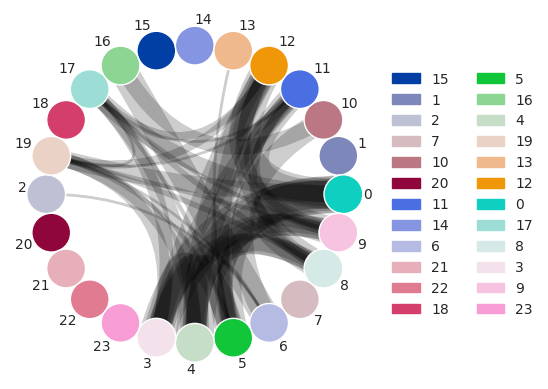

In [28]:
# weighted
ddl.tl.clone_overlap(adata, group_by="leiden", weighted_overlap=True)
ddl.pl.clone_overlap(adata, group_by="leiden", weighted_overlap=True)

There’s also a heatmap on offer.

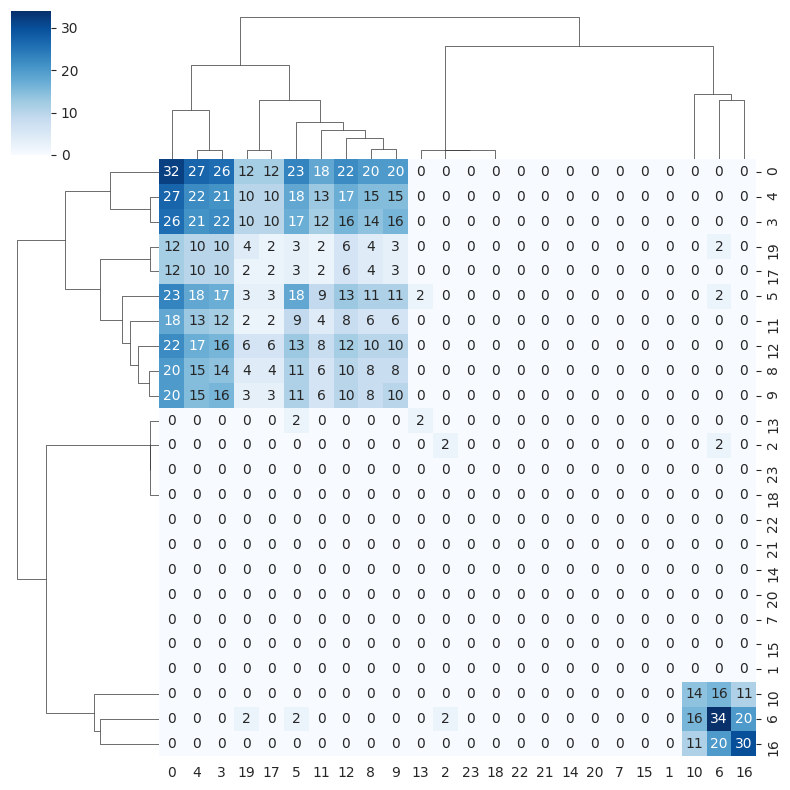

In [29]:
ddl.pl.clone_overlap(
    adata,
    group_by="leiden",
    weighted_overlap=True,
    as_heatmap=True,
    # seaborn clustermap kwargs
    cmap="Blues",
    annot=True,
    figsize=(8, 8),
    annot_kws={"size": 10},
)

And a way to visualise clonotype distributions as a nested circle plot.

min to max ratio is too low at 0.0 and it could cause algorithm stability issues. Try to remove insignificant data


min to max ratio is too low at 0.0 and it could cause algorithm stability issues. Try to remove insignificant data


(<Figure size 700x700 with 1 Axes>, <Axes: >)

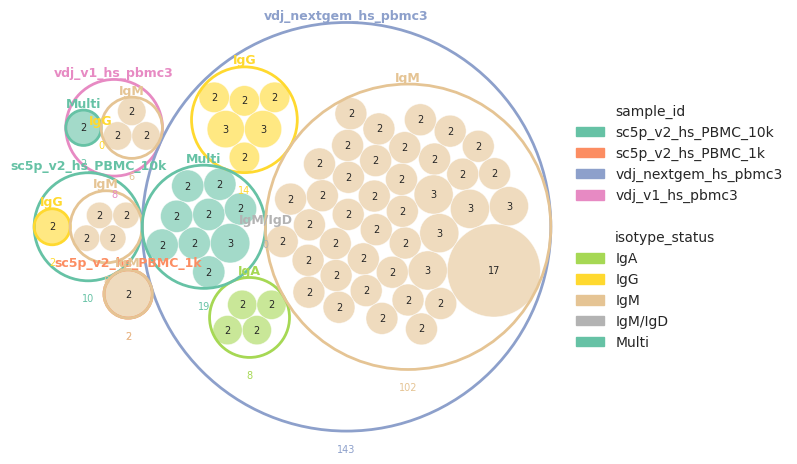

In [30]:
ddl.pl.clone_circlepackplot(
    vdj,
    group_by=["sample_id", "isotype_status"],
    min_clone_size=2,
    show_count_labels=True,
    figsize=(7, 7),
)

Save the objects, like so.

In [31]:
adata.write("demo-gex-processed.h5ad")
vdj.write_h5ddl("demo-vdj-processed.h5ddl")
# or
# vdj.write_zipddl("demo-vdj-processed.zipddl") # use this if you want to preserve the lazy scanning of data (instead of reading entirely into memory)

In [32]:
vdj.data

# V(D)J pseudobulk feature space

This notebook makes use of `Milo` and `Palantir`, two packages that are not formally `Dandelion`’s dependencies. V(D)J feature space applications are open-ended, this is just one of them. Be sure to install the packages beforehand if you want to follow along. `Milo` is now available through `pertpy` package but it can't be installed on Google Colab so are using the soon-to-be archived `milopy` package here. The tutorial at `sc-dandelion.readthedocs.org` has instructions on how to use `pertpy` to access `milo`.

In [33]:
import milopy.core as milo
import palantir
import numpy as np

#required because of Palantir
%matplotlib inline

sc.settings.set_figure_params(dpi=80)

/tmp/ipykernel_1179/67822505.py:8: FutureWarning: Use `scanpy.set_figure_params` instead


We’ve prepared a demo object based on the TCR trajectory shown in the manuscript for you to use here. It’s had some analysis done on the GEX, and has Dandelion-derived contig information merged into it. You can download it from the ftp site as per below.

It’s possible to use V(D)J information that comes from other sources than Dandelion processing, e.g. the pseudobulking will work with Scirpy output. The functions are just calibrated to work with Dandelion’s structure by default.

In [34]:
from dandelion.tutorial import setup_dandelion_tutorial_trajectory

setup_dandelion_tutorial_trajectory()

Downloading...
From (original): https://drive.google.com/uc?id=1-LbAinwhAhJW3Y60wpO9GWJJcaMa_liy
From (redirected): https://drive.google.com/uc?id=1-LbAinwhAhJW3Y60wpO9GWJJcaMa_liy&confirm=t&uuid=182fa3fb-5915-4fcc-89fe-ba858aa80764
To: /content/dandelion_tutorial/panfetal_trajectory/demo-pseudobulk.h5ad
100%|██████████| 401M/401M [00:08<00:00, 49.0MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1lyScJWdGopW2nLoIhZmfUGVSWLWI_qWg
From (redirected): https://drive.google.com/uc?id=1lyScJWdGopW2nLoIhZmfUGVSWLWI_qWg&confirm=t&uuid=c1908bcb-826e-4fa9-a999-2fc2c04083aa
To: /content/dandelion_tutorial/panfetal_trajectory/demo-vdj-traj.tsv.gz
100%|██████████| 28.4M/28.4M [00:01<00:00, 27.7MB/s]


Prior to performing the pseudobulking, it is recommended to run `ddl.tl.setup_vdj_pseudobulk()`. This will subset the object to just cells with paired chains, and prepare appropriately named and formatted columns for the pseudobulking function to use as defaults.

If working with non-Dandelion V(D)J processing, subset your cells to ones with at least a full pair of chains, and ensure that you have four columns in place which contain the V(D)J calls for both of the identified primary chains. Scirpy stores this information natively.

If you are wanting to include D calls (disabled by default), the recommendation is to subset to only cells/contigs with d_call annotated otherwise the separation could be unreliable (due to missing d_call because of technical reasons rather than biology). Please look at the options for `ddl.tl.setup_vdj_pseudobulk()` carefully to tailor to your use case.

We will proceed with the default settings, which is to only consider the primary V and J calls (productive and highest UMI).

In [35]:
adata = sc.read("dandelion_tutorial/panfetal_trajectory/demo-pseudobulk.h5ad")
vdj = ddl.Dandelion("dandelion_tutorial/panfetal_trajectory/demo-vdj-traj.tsv.gz")
adata = ddl.tl.setup_vdj_pseudobulk(adata, vdj)

We’re going to be using `Milo` to create pseudobulks. Construct a neighbour graph with many neighbours, following `Milo`'s protocol, and then sample representative neighbourhoods from the object. This saves a cell-by-pseudobulk matrix into `adata.obsm["nhoods"]`. Use this graph to generate a UMAP as well.

In [36]:
sc.pp.neighbors(adata, use_rep="X_scvi", n_neighbors=50)
milo.make_nhoods(adata)
sc.tl.umap(adata)

/usr/local/lib/python3.12/dist-packages/milopy/core.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.1585212 1.9200459 1.3045591 ... 1.507209  1.2897979 1.2082154]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


Now we are armed with everything we need to construct the V(D)J feature space. Pseudobulks can be defined either via passing a list of `.obs` metadata columns, the unique values of the combination of which will serve as individual pseudobulks (via `obs_to_bulk`), or via an explicit cell-by-pseudobulk matrix (via `pbs`). `Milo` created one of those for us, so we can use that as input.

The cell type annotation lives in `.obs["anno_lvl_2_final_clean"]`. Let’s tell the function that we want to take the most common value per pseudobulk with us to the new V(D)J feature space object.

For non-Dandelion V(D)J processing, use the cols argument to specify which .obs columns contain the V(D)J calls for the identified primary chains. For Scirpy, this would mean specifying e.g. `cols = ['IR_VDJ_1_v_gene', 'IR_VDJ_1_j_gene', 'IR_VJ_1_v_gene', 'IR_VJ_1_j_gene']`.

In [37]:
pb_adata = ddl.tl.vdj_pseudobulk(
    adata, pbs=adata.obsm["nhoods"], obs_to_take="anno_lvl_2_final_clean"
)

/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.


The new object has pseudobulks as observations, and the unique encountered V(D)J genes as the features. We can see the per-pseudobulk annotation, and `.uns["pseudobulk_assigments"]`. In our case it’s just a copy of the `pbs` argument, but if we were to go for `obs_to_bulk` this would be a cells by pseudobulks matrix capturing the assignment of the original cells.

In [38]:
pb_adata

AnnData object with n_obs × n_vars = 1165 × 214
    obs: 'anno_lvl_2_final_clean', 'anno_lvl_2_final_clean_fraction', 'cell_count'
    obsm: 'pbs'

Now that we have our V(D)J feature space pseudobulk object, we can do things with it. Let’s run a PCA on it. The development trajectory is very nicely captured in the first two PC dimensions.

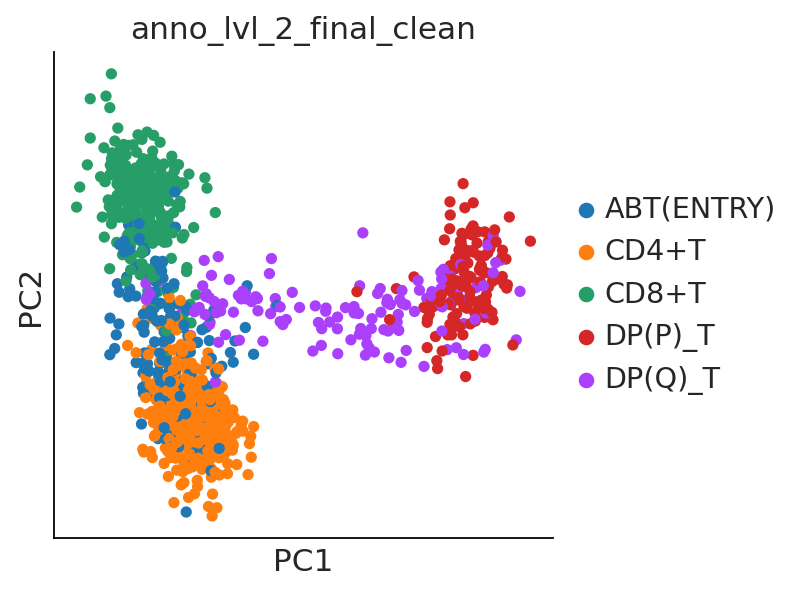

In [39]:
sc.tl.pca(pb_adata)
sc.pl.pca(pb_adata, color="anno_lvl_2_final_clean")

Let’s define the start of our trajectory as the right-most cell, the CD4 terminal state as the bottom-most cell, and the CD8 terminal state as the top-most cell. We can then follow Palantir protocol to generate a diffusion map and run pseudotime. Once done, we rename the terminal states to be more informative.

In [40]:
rootcell = np.argmax(pb_adata.obsm["X_pca"][:, 0])
terminal_states = pd.Series(
    ["CD8+T", "CD4+T"],
    index=pb_adata.obs_names[
        [
            np.argmax(pb_adata.obsm["X_pca"][:, 1]),
            np.argmin(pb_adata.obsm["X_pca"][:, 1]),
        ]
    ],
)

# Run diffusion maps
pca_projections = pd.DataFrame(pb_adata.obsm["X_pca"], index=pb_adata.obs_names)
dm_res = palantir.utils.run_diffusion_maps(pca_projections, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(dm_res)

pr_res = palantir.core.run_palantir(
    ms_data,
    pb_adata.obs_names[rootcell],
    num_waypoints=500,
    terminal_states=terminal_states.index,
)

pr_res.branch_probs.columns = terminal_states[pr_res.branch_probs.columns]

Sampling and flocking waypoints...
Time for determining waypoints: 0.0001617153485616048 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.008126660188039144 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


We can easily transfer the inferred pseudotime and branching probabilities to the pseudobulk object with the aid of a helper function.

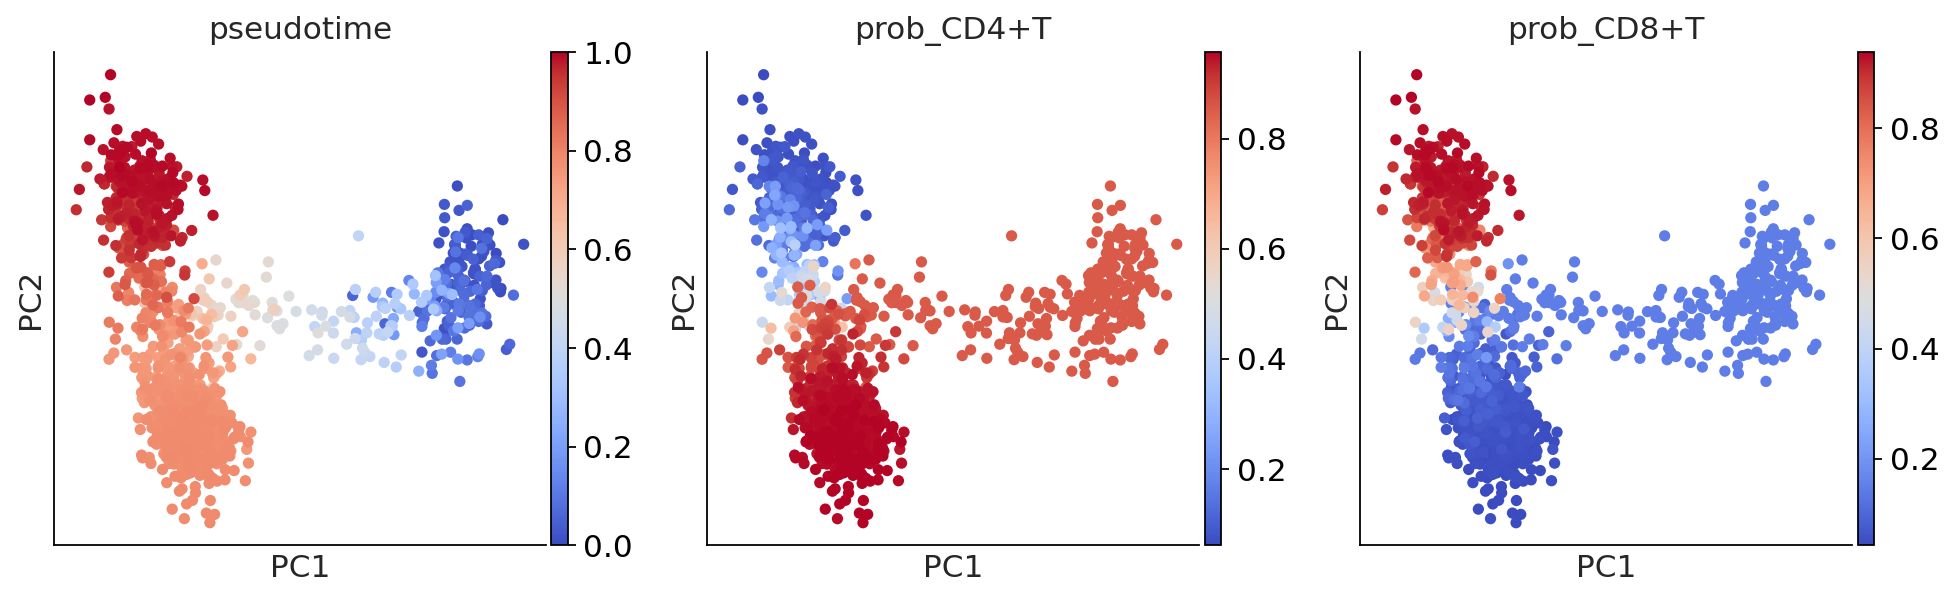

In [41]:
pb_adata = ddl.tl.pseudotime_transfer(pb_adata, pr_res)
sc.pl.pca(
    pb_adata,
    color=["pseudotime", "prob_CD4+T", "prob_CD8+T"],
    color_map="coolwarm",
)

We can project back our findings to the original cell space object via another helper function. This will remove any cells not in any of the pseudobulks. In the event of a cell belonging to multiple pseudobulks, the cell’s pseudotime will be the average of the pseudobulks weighted by the inverse of the pseudobulk size.

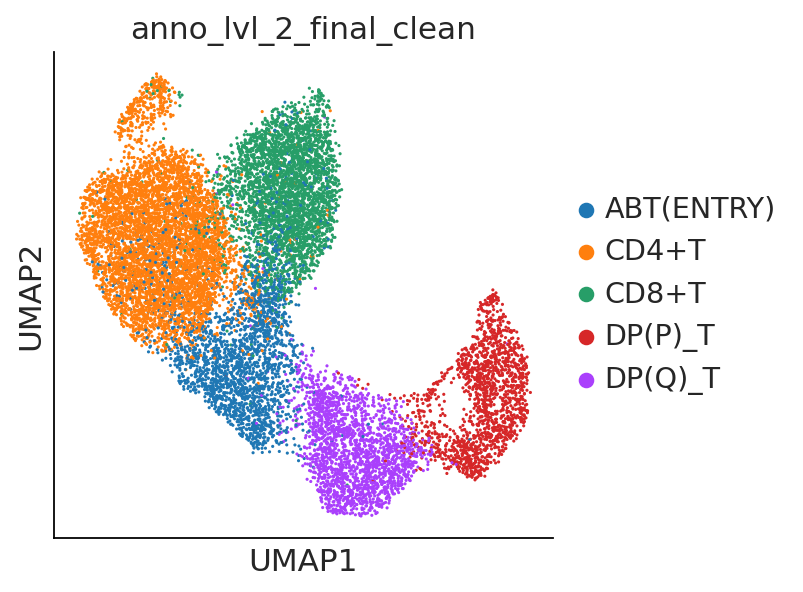

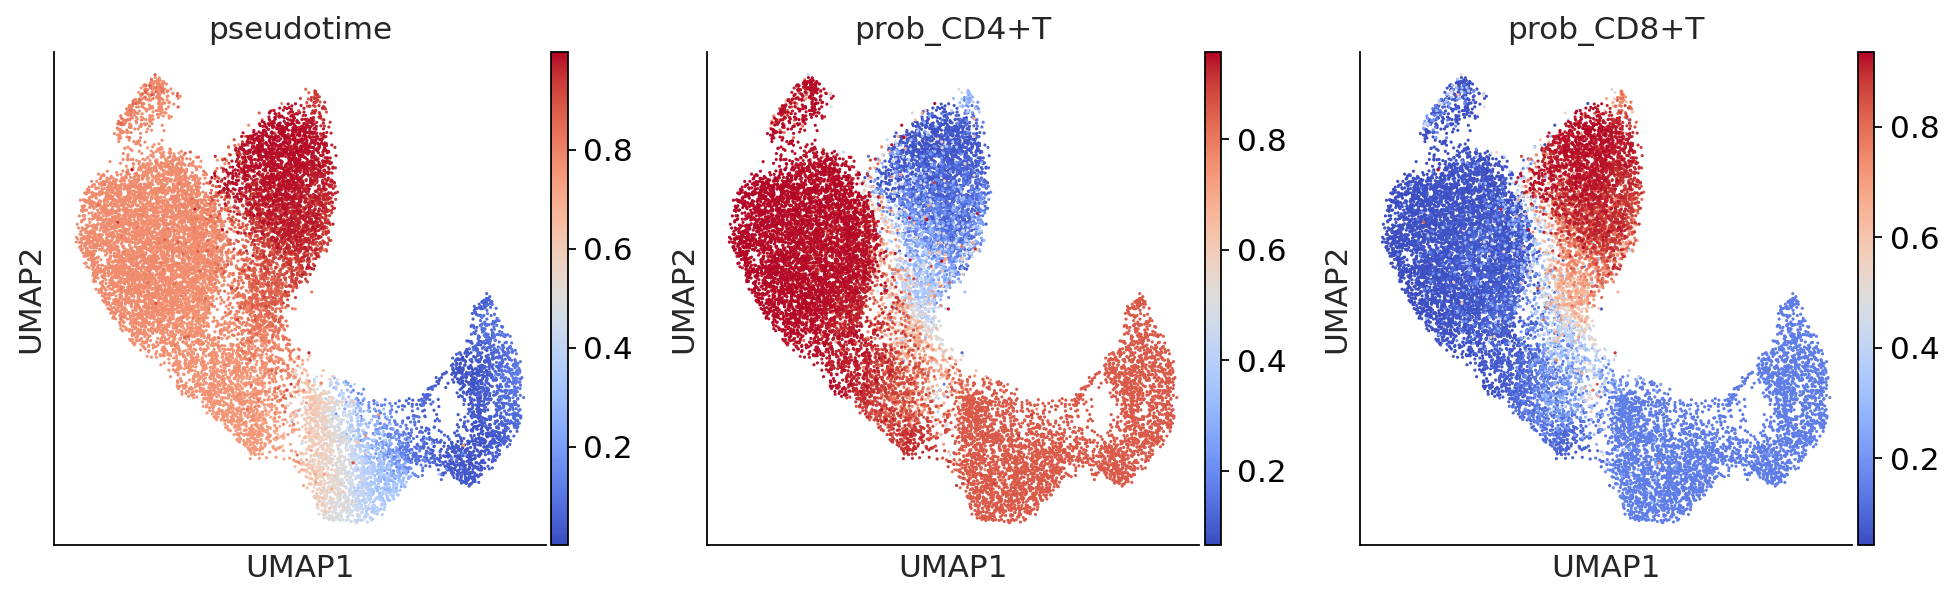

In [42]:
bdata = ddl.tl.project_pseudotime_to_cell(
    adata, pb_adata, terminal_states.values
)
sc.pl.umap(bdata, color=["anno_lvl_2_final_clean"])
sc.pl.umap(
    bdata,
    color=["pseudotime", "prob_CD4+T", "prob_CD8+T"],
    color_map="coolwarm",
)

For more in-depth tutorial and examples of the workflow, please visit `dandelion`'s [documentation](https://sc-dandelion.readthedocs.io/) and [github repository](https://github.com/tuonglab/dandelion).